# Machine learning Basics

* Types of ML
1. Supervised ML
  * Classification
  * Regression
2. Unsupervised ML
  * Clustering
3. Reinforcement Learning

* Confusion Matrix
* Encoding Techniques
  1.  Label Encoding
  2.  One Hot Encoding
  3. Ordinal Encoding
* Feature Scaling
  * Standard Scaler
  * Normalization
    1. MinMax Scalar
    2. MaxAbs Scalar




# Confusion Matrix
* A confusion matrix is a table that summarizes a classification model's performance by comparing its predicted labels with the actual labels.

1. Type-I Error [Falsse Positive]
2. Type-II Error [False Negative]

Accuracy = [ (True Positive + True Negative)/ (Total Prediction) ]

# Encoding Techniques
* Encoding techniques are methods used to convert categorical data into numerical values so machine learning algorithms can process them.

In [ ]:
import pandas as pd

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uditjain13/social-media-screen-time-and-mental-health-2026")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'social-media-screen-time-and-mental-health-2026' dataset.
Path to dataset files: /kaggle/input/social-media-screen-time-and-mental-health-2026


In [ ]:
SM = pd.read_csv(f"{path}/social_media_screentime_mental_health_2026.csv")

In [ ]:
SM.head()

,participant_id,age,gender,occupation,region,most_used_platform,platforms_used_count,daily_screen_hours,daily_notifications,night_time_use,...,life_satisfaction_1to10,loneliness_1to10,self_esteem_1to10,fomo_1to10,social_comparison_1to10,physical_activity_days_per_week,uses_screen_time_limits,attempted_digital_detox,seeks_mental_health_support,wellbeing_band
0,P300000,33,Male,Student,Latin America,TikTok,8,3.2,172,Never,...,9,6,4,6,8,4,No,No,No,At-risk
1,P300001,23,Female,Full-time employed,Oceania,Instagram,8,4.5,38,Often,...,7,5,8,5,8,4,No,"Yes, failed",Yes,At-risk
2,P300002,56,Female,Full-time employed,Africa,Instagram,1,5.3,74,Every night,...,8,7,3,2,3,5,No,No,No,Moderate
3,P300003,13,Male,Student,Europe,YouTube,4,3.4,49,Sometimes,...,10,6,6,1,5,4,No,"Yes, failed",Yes,Moderate
4,P300004,36,Female,Student,Asia,LinkedIn,5,5.8,227,Never,...,4,6,8,7,9,3,Yes,"Yes, succeeded",No,Moderate


# Label Encoding
* Assigns a unique integer to each category.

In [ ]:
from sklearn.preprocessing import LabelEncoder

obj = LabelEncoder()

In [ ]:
SM['Encode'] = obj.fit_transform(SM['most_used_platform'])
print(SM['Encode'])

0       5
1       1
2       1
3       7
4       2
       ..
6995    4
6996    0
6997    2
6998    4
6999    0
Name: Encode, Length: 7000, dtype: int64


In [ ]:
SM[['Encode','most_used_platform']]

,Encode,most_used_platform
0,5,TikTok
1,1,Instagram
2,1,Instagram
3,7,YouTube
4,2,LinkedIn
...,...,...
6995,4,Snapchat
6996,0,Facebook
6997,2,LinkedIn
6998,4,Snapchat


# One Hot Encoding
* Creates a separate binary column for each category.

In [ ]:
En = pd.get_dummies(SM['most_used_platform'],dtype = int)
En

,Facebook,Instagram,LinkedIn,Reddit,Snapchat,TikTok,X/Twitter,YouTube
0,0,0,0,0,0,1,0,0
1,0,1,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0
3,0,0,0,0,0,0,0,1
4,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...
6995,0,0,0,0,1,0,0,0
6996,1,0,0,0,0,0,0,0
6997,0,0,1,0,0,0,0,0
6998,0,0,0,0,1,0,0,0


# Ordinal Encoding
* Used when categories have a natural order.

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

O = OrdinalEncoder()

In [ ]:
SM['New'] = O.fit_transform(SM[['occupation']])
SM[['New','occupation']]

,New,occupation
0,4.0,Student
1,0.0,Full-time employed
2,0.0,Full-time employed
3,4.0,Student
4,4.0,Student
...,...,...
6995,1.0,Part-time employed
6996,3.0,Self-employed
6997,5.0,Unemployed
6998,4.0,Student


ML Pipeline (Flow)

Import Libraries ▶ Import Dataset ▶ Understand Data ▶ Data Preprocessing ▶ EDA ▶ Model Selection ▶ Model Training ▶ Prediction (PKL) ▶ Evaluation ▶ Deployment

# Student Exam Scores Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mirzayasirabdullah07/student-exam-scores-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'student-exam-scores-dataset' dataset.
Path to dataset files: /kaggle/input/student-exam-scores-dataset


In [ ]:
Stu = pd.read_csv(f"{path}/student_exam_scores.csv")
Stu.head()

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,60.7,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3


In [ ]:
Stu.shape

(200, 6)

In [ ]:
Stu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          200 non-null    object 
 1   hours_studied       200 non-null    float64
 2   sleep_hours         200 non-null    float64
 3   attendance_percent  200 non-null    float64
 4   previous_scores     200 non-null    int64  
 5   exam_score          200 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 9.5+ KB


In [ ]:
Stu.columns

Index(['student_id', 'hours_studied', 'sleep_hours', 'attendance_percent',
       'previous_scores', 'exam_score'],
      dtype='object')

In [ ]:
Stu.describe()

,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,6.325500,6.622000,74.830000,66.800000,33.955000
std,3.227317,1.497138,14.249905,15.663869,6.789548
min,1.000000,4.000000,50.300000,40.000000,17.100000
25%,3.500000,5.300000,62.200000,54.000000,29.500000
50%,6.150000,6.700000,75.250000,67.500000,34.050000
75%,9.000000,8.025000,87.425000,80.000000,38.750000
max,12.000000,9.000000,100.000000,95.000000,51.300000


In [ ]:
Stu.isna().sum()

,0
student_id,0
hours_studied,0
sleep_hours,0
attendance_percent,0
previous_scores,0
exam_score,0


In [ ]:
Stu.duplicated().sum()

np.int64(0)

In [ ]:
Stu.max()

,0
student_id,S200
hours_studied,12.0
sleep_hours,9.0
attendance_percent,100.0
previous_scores,95
exam_score,51.3


In [ ]:
Stu.min()

,0
student_id,S001
hours_studied,1.0
sleep_hours,4.0
attendance_percent,50.3
previous_scores,40
exam_score,17.1


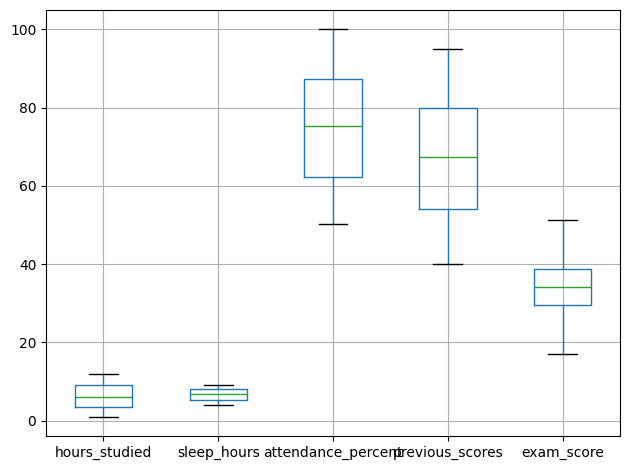

In [ ]:
Stu.boxplot()
plt.tight_layout()
plt.show()

<Axes: >

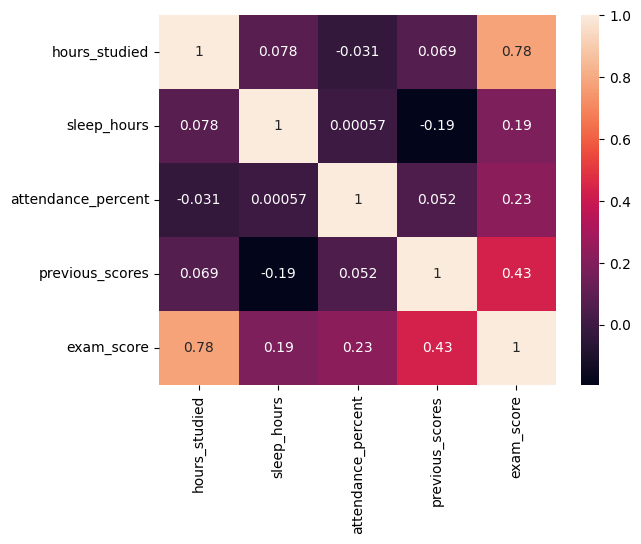

In [ ]:
sns.heatmap(data = Stu.corr(numeric_only = True), annot = True)

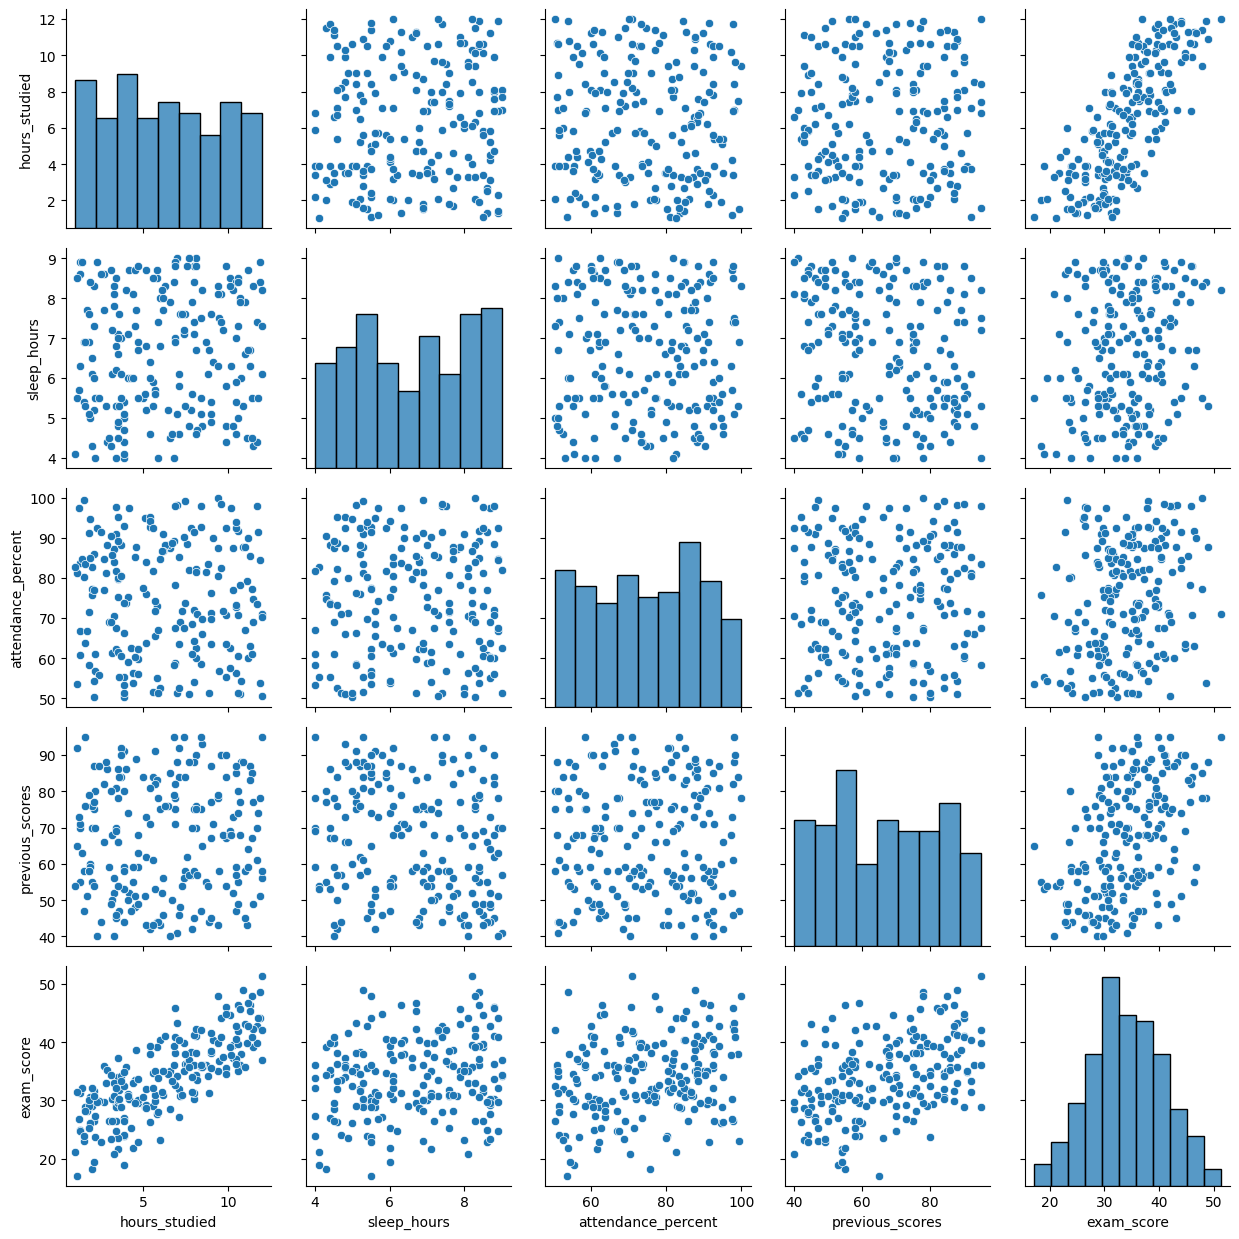

In [ ]:
sns.pairplot(Stu)
plt.tight_layout()
plt.show()

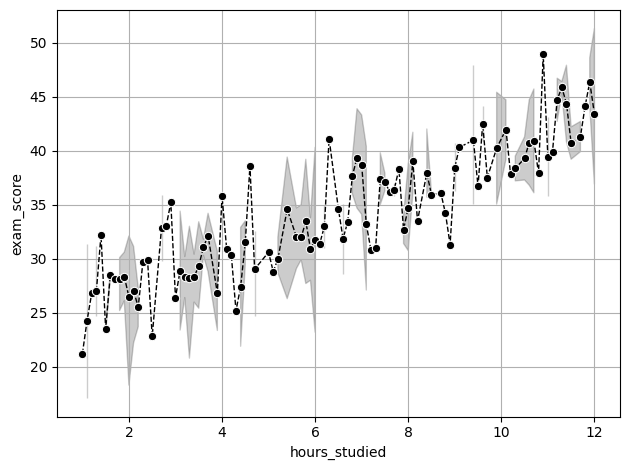

In [ ]:
sns.lineplot(x = 'hours_studied', y = 'exam_score', data = Stu, marker = 'o', color = 'black', linestyle = '--', linewidth = 1)
plt.tight_layout()
plt.grid()

# K-NN (K-Nearest Neighbors)
* A simple supervised machine learning algorithm that classifies or predicts a data point by looking at the **K** closest data points in the training set and making a decision based on their labels or values. It is easy to understand and works well for both classification and regression tasks.


In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [ ]:
Stu = Stu.drop(columns = ['student_id'])

In [ ]:
Stu.head(1)

,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,8.0,8.8,72.1,45,30.2


In [ ]:
X = Stu[['hours_studied', 'sleep_hours', 'attendance_percent',
       'previous_scores']]
Y = Stu['exam_score']

In [ ]:
X_train, X_test, Y_train, Y_test  = train_test_split(X, Y, test_size = 0.2, random_state = 43)

In [ ]:
Exam_score_Predictor = KNeighborsRegressor(n_neighbors = 5)
Exam_score_Predictor

KNeighborsRegressor()

In [ ]:
Exam_score_Predictor.fit(X_train, Y_train)

KNeighborsRegressor()

In [ ]:
Predict = Exam_score_Predictor.predict(X_test)
Predict

array([36.34, 37.06, 28.02, 35.96, 34.  , 28.22, 27.22, 35.44, 36.26,
       30.92, 36.66, 32.54, 39.02, 42.38, 41.82, 34.68, 40.48, 27.22,
       32.58, 32.98, 33.  , 34.6 , 39.2 , 39.  , 33.64, 35.82, 28.84,
       37.24, 29.56, 29.58, 38.52, 31.42, 26.94, 34.96, 29.24, 30.24,
       37.04, 28.08, 38.8 , 40.32])

In [ ]:
Score = r2_score(Y_test, Predict)
print(Score*100)

66.60422880373869


In [ ]:
import pickle

In [ ]:
pickle.dump(Exam_score_Predictor, open('Exam_score_Predictor.pkl','wb'))
print('pkl file created succesfully')

pkl file created succesfully


# Naive Bayes Algorithm
* The Naive Bayes algorithm is a supervised machine learning classification algorithm based on Bayes' Theorem. It is called "naive" because it assumes that all features (input variables) are independent of each other, even though this assumption is often not true in real-world data.

Types of Naive Bayes
1. Gaussian Naive Bayes
* Used for continuous numerical data.
* Assumes data follows a normal (Gaussian) distribution.
2. Multinomial Naive Bayes
* Used for text classification and word counts.
* Commonly used in spam detection and document classification.
3. Bernoulli Naive Bayes
* Used for binary features (0/1, Yes/No).

# Social_Network_Ads Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rakeshrau/social-network-ads")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'social-network-ads' dataset.
Path to dataset files: /kaggle/input/social-network-ads


In [ ]:
SN = pd.read_csv(f"{path}/Social_Network_Ads.csv")

In [ ]:
SN.shape

(400, 4)

In [ ]:
SN.head(2)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0


In [ ]:
SN.isna().sum()

,0
User ID,0
Gender,0
Age,0
EstimatedSalary,0
Purchased,0


In [ ]:
SN.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [ ]:
SN.duplicated().sum()

np.int64(0)

In [ ]:
SN.columns

Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')

In [ ]:
SN = SN.drop(columns=['User ID'])

In [ ]:
SN.columns

Index(['Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')

In [ ]:
gen = LabelEncoder()
SN['Gender'] = gen.fit_transform(SN['Gender'])

In [ ]:
SN.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Gender           400 non-null    int64
 1   Age              400 non-null    int64
 2   EstimatedSalary  400 non-null    int64
 3   Purchased        400 non-null    int64
dtypes: int64(4)
memory usage: 12.6 KB


In [ ]:
SN.head(1)

,Gender,Age,EstimatedSalary,Purchased
0,1,19,19000,0


In [ ]:
X = SN[['Gender', 'Age', 'EstimatedSalary']]
Y = SN['Purchased']

In [ ]:
X_train, X_test, Y_train, Y_test  = train_test_split(X, Y, test_size = 0.2, random_state = 42)

In [ ]:
Purchase_Prediction = GaussianNB()
Purchase_Prediction.fit(X_train, Y_train)

GaussianNB()

In [ ]:
predict = Purchase_Prediction.predict(X_test)
predict

array([1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0])

In [ ]:
Score = accuracy_score(Y_test, predict)
print('Accuracy', Score*100)

Accuracy 93.75


In [ ]:
import pickle
pickle.dump(Purchase_Prediction, open('Purchase_Prediction.pkl','wb'))
print('pkl file created succesfully')

pkl file created succesfully


# Support Vector Machine

A Support Vector Machine (SVM) is a supervised machine learning algorithm that finds the optimal boundary (hyperplane) to separate data into different classes with the maximum margin.

Types of SVM:

1. Linear SVM – Used when the data is linearly separable.
2. Non-Linear SVM – Used when the data is not linearly separable, using kernel functions such as:

   * Polynomial Kernel
   * Radial Basis Function (RBF) Kernel
   * Sigmoid Kernel

Alternative classification:

* C-SVM (Classification SVM) – Used for classification tasks.
* SVR (Support Vector Regression) – Used for regression tasks.

Basic terms and concepts of Support Vector Machine (SVM):

1. Hyperplane – The decision boundary that separates different classes of data.
2. Support Vectors – The data points closest to the hyperplane; they determine its position.
3. Margin – The distance between the hyperplane and the nearest support vectors. SVM aims to maximize this margin.
4. Maximum Margin – The largest possible distance between the hyperplane and the support vectors, improving generalization.
5. Kernel Function – A function that transforms non-linear data into a higher-dimensional space to make it linearly separable.

   * Common kernels:

     * Linear Kernel
     * Polynomial Kernel
     * RBF (Gaussian) Kernel
     * Sigmoid Kernel
6. Linear SVM – Used when data can be separated by a straight line (or hyperplane).
7. Non-Linear SVM – Used when data cannot be separated linearly; relies on kernel functions.
8. Soft Margin – Allows some misclassified data points to improve performance on noisy datasets.
9. Hard Margin – Assumes perfectly separable data with no misclassification.
10. Regularization Parameter (C) – Controls the trade-off between maximizing the margin and minimizing classification errors.

* SVM works by finding the best hyperplane with the maximum margin, using support vectors, and kernel functions when the data is not linearly separable.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mubashirsidiki/student-academic-performance-500-students")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'student-academic-performance-500-students' dataset.
Path to dataset files: /kaggle/input/student-academic-performance-500-students


In [ ]:
SP = pd.read_csv(f"{path}/student_performance.csv")

In [ ]:
SP.shape

(500, 11)

In [ ]:
SP.head(2)

,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,STU0001,Male,15,25,63.8,Bachelor,Yes,Yes,41,67,Yes
1,STU0002,Female,15,2,54.7,Bachelor,Yes,Yes,83,28,No


In [ ]:
SP.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            500 non-null    object 
 1   gender                500 non-null    object 
 2   age                   500 non-null    int64  
 3   study_hours_per_week  500 non-null    int64  
 4   attendance_rate       500 non-null    float64
 5   parent_education      383 non-null    object 
 6   internet_access       500 non-null    object 
 7   extracurricular       500 non-null    object 
 8   previous_score        500 non-null    int64  
 9   final_score           500 non-null    int64  
 10  passed                500 non-null    object 
dtypes: float64(1), int64(4), object(6)
memory usage: 43.1+ KB


In [ ]:
SP.describe()

,age,study_hours_per_week,attendance_rate,previous_score,final_score
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,16.978000,15.312000,76.380600,62.986000,55.980000
std,1.434445,8.568167,13.817681,18.937451,15.373754
min,15.000000,2.000000,50.200000,30.000000,20.000000
25%,16.000000,8.000000,64.475000,46.000000,45.000000
50%,17.000000,15.000000,76.500000,64.000000,56.000000
75%,18.000000,23.000000,88.525000,79.000000,68.000000
max,19.000000,30.000000,100.000000,95.000000,95.000000


In [ ]:
SP.isna().sum()

,0
student_id,0
gender,0
age,0
study_hours_per_week,0
attendance_rate,0
parent_education,117
internet_access,0
extracurricular,0
previous_score,0
final_score,0


In [ ]:
SP['parent_education'].unique()

array(['Bachelor', 'High School', 'Master', nan, 'PhD'], dtype=object)

In [ ]:
SP['parent_education'] = SP['parent_education'].fillna(SP['parent_education'].mode())

In [ ]:
SP = SP.drop(columns = ['student_id'])

In [ ]:
SP.columns

Index(['gender', 'age', 'study_hours_per_week', 'attendance_rate',
       'parent_education', 'internet_access', 'extracurricular',
       'previous_score', 'final_score', 'passed'],
      dtype='object')

In [ ]:
LE = LabelEncoder()

In [ ]:
SP['gender'] = LE.fit_transform(SP['gender'])
print(SP['gender'])

0      1
1      0
2      0
3      1
4      0
      ..
495    0
496    0
497    0
498    1
499    1
Name: gender, Length: 500, dtype: int64


In [ ]:
SP['parent_education'] = LE.fit_transform(SP['parent_education'])
print(SP['parent_education'])

0      0
1      0
2      1
3      1
4      1
      ..
495    2
496    3
497    2
498    4
499    1
Name: parent_education, Length: 500, dtype: int64


In [ ]:
SP['internet_access'] = LE.fit_transform(SP['internet_access'])
print(SP['internet_access'])


0      1
1      1
2      1
3      0
4      0
      ..
495    0
496    0
497    0
498    1
499    0
Name: internet_access, Length: 500, dtype: int64


In [ ]:
SP['extracurricular'] = LE.fit_transform(SP['extracurricular'])
print(SP['extracurricular'])

0      1
1      1
2      0
3      1
4      1
      ..
495    0
496    0
497    1
498    0
499    1
Name: extracurricular, Length: 500, dtype: int64


In [ ]:
SP['passed'] = LE.fit_transform(SP['passed'])
print(SP['passed'])

0      1
1      0
2      0
3      1
4      1
      ..
495    0
496    1
497    1
498    1
499    1
Name: passed, Length: 500, dtype: int64


In [ ]:
SP.head()

,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,1,15,25,63.8,0,1,1,41,67,1
1,0,15,2,54.7,0,1,1,83,28,0
2,0,19,10,90.5,1,1,0,73,49,0
3,1,16,26,66.8,1,0,1,75,70,1
4,0,15,25,73.0,1,0,1,67,77,1


In [ ]:
X = SP[['gender', 'age', 'study_hours_per_week', 'attendance_rate',
       'parent_education', 'internet_access', 'extracurricular',
       'previous_score', 'final_score']]
Y = SP['passed']

In [ ]:
X_train, X_test, Y_train, Y_test  = train_test_split(X, Y, test_size = 0.2, random_state = 40)

In [ ]:
Passed_or_Failed = SVC()
Passed_or_Failed.fit(X_train, Y_train)

SVC()

In [ ]:
Predict = Passed_or_Failed.predict(X_test)
Predict

array([1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0])

In [ ]:
Score = accuracy_score(Y_test, Predict)
print('Accuracy', Score*100)

Accuracy 99.0


In [ ]:
import pickle
pickle.dump(Passed_or_Failed, open('Passed_or_Failed.pkl','wb'))
print('pkl file created succesfully')

pkl file created succesfully


# Linear Regression
* Linear Regression is a supervised machine learning algorithm used to predict a continuous numerical value by finding the best-fit straight line between input features and the target variable.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sukhmandeepsinghbrar/house-prices-india")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'house-prices-india' dataset.
Path to dataset files: /kaggle/input/house-prices-india


In [ ]:
HP = pd.read_csv(f"{path}/House Price India.csv")

In [ ]:
HP.shape

(14619, 23)

In [ ]:
HP.head()

,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,grade of the house,Area of the house(excluding basement),Area of the basement,Built Year,Renovation Year,Postal Code,lot_area_renov,Number of schools nearby,Distance from the airport,Price
0,4,2.50,2920,4000,1.5,0,0,5,8,1910,1010,1909,0,122004,4000,2,51,1400000
1,5,2.75,2910,9480,1.5,0,0,3,8,2910,0,1939,0,122004,6600,1,53,1200000
2,4,2.50,3310,42998,2.0,0,0,3,9,3310,0,2001,0,122005,42847,3,76,838000
3,3,2.00,2710,4500,1.5,0,0,4,8,1880,830,1929,0,122006,4500,1,51,805000
4,3,2.50,2600,4750,1.0,0,0,4,9,1700,900,1951,0,122007,4750,1,67,790000


In [ ]:
HP.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14619 entries, 0 to 14618
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     14619 non-null  int64  
 1   Date                                   14619 non-null  int64  
 2   number of bedrooms                     14619 non-null  int64  
 3   number of bathrooms                    14619 non-null  float64
 4   living area                            14619 non-null  int64  
 5   lot area                               14619 non-null  int64  
 6   number of floors                       14619 non-null  float64
 7   waterfront present                     14619 non-null  int64  
 8   number of views                        14619 non-null  int64  
 9   condition of the house                 14619 non-null  int64  
 10  grade of the house                     14619 non-null  int64  
 11  Ar

In [ ]:
HP.describe().sum()

,0
id,4.057695e+10
Date,2.703239e+05
number of bedrooms,1.466732e+04
number of bathrooms,1.463690e+04
living area,3.749538e+04
lot area,1.165802e+06
number of floors,1.463004e+04
waterfront present,1.462009e+04
number of views,1.462400e+04
condition of the house,1.463909e+04


In [ ]:
HP.isna().sum()

,0
id,0
Date,0
number of bedrooms,0
number of bathrooms,0
living area,0
lot area,0
number of floors,0
waterfront present,0
number of views,0
condition of the house,0


In [ ]:
HP.duplicated().sum()

np.int64(0)

In [ ]:
HP.columns

Index(['id', 'Date', 'number of bedrooms', 'number of bathrooms',
       'living area', 'lot area', 'number of floors', 'waterfront present',
       'number of views', 'condition of the house', 'grade of the house',
       'Area of the house(excluding basement)', 'Area of the basement',
       'Built Year', 'Renovation Year', 'Postal Code', 'Lattitude',
       'Longitude', 'living_area_renov', 'lot_area_renov',
       'Number of schools nearby', 'Distance from the airport', 'Price'],
      dtype='object')

In [ ]:
HP = HP.drop(columns = ['id', 'Date','Lattitude', 'Longitude','living_area_renov'])

In [ ]:
HP.columns

Index(['number of bedrooms', 'number of bathrooms', 'living area', 'lot area',
       'number of floors', 'waterfront present', 'number of views',
       'condition of the house', 'grade of the house',
       'Area of the house(excluding basement)', 'Area of the basement',
       'Built Year', 'Renovation Year', 'Postal Code', 'lot_area_renov',
       'Number of schools nearby', 'Distance from the airport', 'Price'],
      dtype='object')

In [ ]:
X = HP[['number of bedrooms', 'number of bathrooms', 'living area', 'lot area',
       'number of floors', 'waterfront present', 'number of views',
       'condition of the house', 'grade of the house',
       'Area of the house(excluding basement)', 'Area of the basement',
       'Built Year', 'Renovation Year', 'Postal Code', 'lot_area_renov',
       'Number of schools nearby', 'Distance from the airport']]
Y = HP['Price']

In [ ]:
X.count().sum()

np.int64(248523)

In [ ]:
Y.count().sum()

np.int64(14619)

In [ ]:
X_train, X_test, Y_train, Y_test  = train_test_split(X, Y, test_size = 0.2, random_state = 42)

In [ ]:
House_Price = LinearRegression()
House_Price.fit(X_train, Y_train)

LinearRegression()

In [ ]:
Predict = House_Price.predict(X_test)
Predict

array([ 526803.46087609,  547845.51481453,  426805.30732261, ...,
        692715.16767055,  437905.53726952, 1969847.01451069])

In [ ]:
Score = r2_score(Y_test, Predict)
print('Accuracy', Score*100)

Accuracy 66.91215533271597


In [ ]:
error = mean_squared_error(Y_test, Predict)
print(error)

48968710281.472755


In [ ]:
import pickle
pickle.dump(House_Price, open('Houes_Price_Prediction.pkl','wb'))
print('pkl file created succesfully')

pkl file created succesfully


# Logistic Regression
* Logistic Regression is a supervised machine learning algorithm used for classification problems. Despite its name, it is used to predict categorical outcomes (such as Yes/No, Spam/Not Spam, Disease/No Disease) rather than continuous values.

Types of Logistic Regression
 1. Binary Logistic Regression
* Two output classes.
* Example: Pass/Fail, Yes/No.
 2. Multinomial Logistic Regression
* More than two unordered classes.
* Example: Predicting fruit type (Apple, Banana, Orange).
 3. Ordinal Logistic Regression
* Output classes have an order.
* Example: Poor, Average, Good, Excellent.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tawfikelmetwally/employee-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'employee-dataset' dataset.
Path to dataset files: /kaggle/input/employee-dataset


In [ ]:
ED = pd.read_csv(f"{path}/Employee.csv")

In [ ]:
ED.head()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1


In [ ]:
ED.shape

(4653, 9)

In [ ]:
ED.isna().sum()

,0
Education,0
JoiningYear,0
City,0
PaymentTier,0
Age,0
Gender,0
EverBenched,0
ExperienceInCurrentDomain,0
LeaveOrNot,0


In [ ]:
ED.duplicated().sum()

np.int64(1889)

In [ ]:
ED = ED.drop_duplicates()

In [ ]:
ED.duplicated().sum()

np.int64(0)

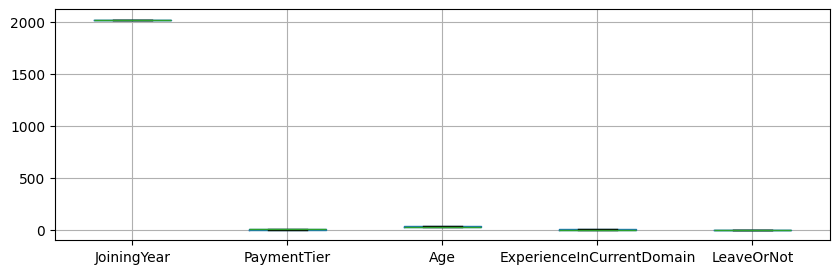

In [ ]:
plt.figure(figsize = (10,3))
ED.boxplot()
plt.show()

In [ ]:
LE = LabelEncoder()

In [ ]:
ED['Education'] = LE.fit_transform(ED['Education'])
ED['Gender'] = LE.fit_transform(ED['Gender'])
ED['City'] = LE.fit_transform(ED['City'])
ED['EverBenched'] = LE.fit_transform(ED['EverBenched'])


In [ ]:
ED.head()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,0,2017,0,3,34,1,0,0,0
1,0,2013,2,1,28,0,0,3,1
2,0,2014,1,3,38,0,0,2,0
3,1,2016,0,3,27,1,0,5,1
4,1,2017,2,3,24,1,1,2,1


In [ ]:
ED.columns

Index(['Education', 'JoiningYear', 'City', 'PaymentTier', 'Age', 'Gender',
       'EverBenched', 'ExperienceInCurrentDomain', 'LeaveOrNot'],
      dtype='object')

In [ ]:
X = ED[['Education', 'JoiningYear', 'City', 'PaymentTier', 'Age', 'Gender',
       'EverBenched', 'ExperienceInCurrentDomain']]
Y = ED['LeaveOrNot']

In [ ]:
X_train, X_test, Y_train, Y_test  = train_test_split(X, Y, test_size = 0.2, random_state = 45)

In [ ]:
Emp_Stay_Leave = LogisticRegression(max_iter=1000)
Emp_Stay_Leave.fit(X_train, Y_train)

LogisticRegression(max_iter=1000)

In [ ]:
Predict = Emp_Stay_Leave.predict(X_test)
Predict

array([0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
Score = accuracy_score(Y_test,Predict)
print(Score*100)

67.08860759493672


In [ ]:
import pickle
pickle.dump(Emp_Stay_Leave, open('Emp_Stay_leave_Prediction.pkl','wb'))
print('pkl file created succesfully')

pkl file created succesfully


# Decision Tree

* A Decision Tree is a supervised machine learning algorithm used for classification and regression tasks. It predicts the target value by learning simple decision rules from the data.

How It Works
* A decision tree divides the dataset into smaller subsets based on feature values. Each split is chosen to best separate the data.

The tree consists of:

* Root Node: The starting point that represents the entire dataset.
* Decision Nodes: Internal nodes where the data is split based on a feature.
* Leaf Nodes: Terminal nodes that give the final prediction (class label or numerical value).
* Example
  Suppose we want to predict whether a student will pass an exam.

                 Study Hours > 5?
                 /             \
              Yes               No
             /                   \
      Attendance > 75?         Fail
          /      \
       Yes        No
      Pass       Fail

* If a student studies more than 5 hours and has attendance above 75%, the prediction is Pass.
* Otherwise, the prediction is Fail.


* Steps in Building a Decision Tree
1. Start with the entire dataset.
2. Select the best feature for splitting.
3. Divide the dataset into subsets.
4. Repeat the process for each subset.
5. Stop when:
  * All samples belong to the same class.
  * Maximum tree depth is reached.
  * Minimum number of samples is reached.


* Splitting Criteria

  * For Classification:

    1. Entropy
    2. Information Gain (used in ID3)
    3. Gini Index (used in CART)

Entropy Formula:

Entropy(S)=−∑pilog2(pi)

Information Gain:

IG=Entropy(Parent)−Weighted Entropy(Children)

Information Gain(S,A)= Entropy(S) − v∈A∑​∣S∣/∣Sv​∣ ​× Entropy(Sv​)

Gini Index:

Gini=1−∑pi^2
	​


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("waddahali/fraud-detection")

print("Path to dataset files:", path)

100%|██████████| 321k/321k [00:00<00:00, 470kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/waddahali/fraud-detection/versions/1


In [ ]:
FD = pd.read_csv(f"{path}/fraud.csv")

In [ ]:
FD.shape

(7000, 13)

In [ ]:
FD.head()

,transaction_amount,hour_of_day,is_weekend,num_items,customer_age,prev_transactions,distance_from_home,device_type,network_quality,is_first_transaction,store_type,velocity_score,is_fraud
0,161.363691,3.0,0.0,2.0,18.000000,2.0,26.539742,1.0,48.403937,0.0,0.0,3.718296,0
1,116.202851,1.0,1.0,4.0,26.285818,2.0,50.714402,NaN,76.144979,0.0,0.0,4.951272,0
2,1.000000,2.0,0.0,5.0,18.000000,NaN,9.467935,0.0,67.600316,0.0,0.0,4.556043,0
3,48.780618,2.0,0.0,3.0,44.471190,NaN,41.077068,0.0,94.825526,0.0,0.0,6.918437,0
4,NaN,3.0,0.0,4.0,38.733609,8.0,NaN,2.0,100.000000,0.0,1.0,5.535335,1


In [ ]:
FD.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   transaction_amount    6440 non-null   float64
 1   hour_of_day           6650 non-null   float64
 2   is_weekend            6860 non-null   float64
 3   num_items             6790 non-null   float64
 4   customer_age          6160 non-null   float64
 5   prev_transactions     6510 non-null   float64
 6   distance_from_home    6300 non-null   float64
 7   device_type           6720 non-null   float64
 8   network_quality       6370 non-null   float64
 9   is_first_transaction  6790 non-null   float64
 10  store_type            6860 non-null   float64
 11  velocity_score        5950 non-null   float64
 12  is_fraud              7000 non-null   int64  
dtypes: float64(12), int64(1)
memory usage: 711.1 KB


In [ ]:
FD.describe()

,transaction_amount,hour_of_day,is_weekend,num_items,customer_age,prev_transactions,distance_from_home,device_type,network_quality,is_first_transaction,store_type,velocity_score,is_fraud
count,6440.000000,6650.000000,6860.000000,6790.000000,6160.000000,6510.000000,6300.000000,6720.000000,6370.000000,6790.000000,6860.000000,5950.000000,7000.000000
mean,100.014648,2.200902,0.108601,2.977320,36.200811,4.457604,24.830735,0.698810,74.094739,0.095876,0.286735,5.007450,0.103000
std,49.091009,0.677906,0.311160,1.712444,13.283996,4.881635,24.314751,0.776802,18.003855,0.294443,0.452270,2.007633,0.303981
min,1.000000,1.000000,0.000000,0.000000,18.000000,0.000000,0.004282,0.000000,0.477174,0.000000,0.000000,-1.853966,0.000000
25%,65.711569,2.000000,0.000000,2.000000,25.244168,1.000000,7.387315,0.000000,61.586731,0.000000,0.000000,3.697990,0.000000
50%,99.482201,2.000000,0.000000,3.000000,35.361187,3.000000,17.321496,1.000000,75.306346,0.000000,0.000000,4.992099,0.000000
75%,132.897923,3.000000,0.000000,4.000000,45.500089,6.000000,34.857859,1.000000,88.253574,0.000000,1.000000,6.342852,0.000000
max,296.311885,3.000000,1.000000,13.000000,80.000000,40.000000,224.699757,2.000000,100.000000,1.000000,1.000000,12.659564,1.000000


In [ ]:
FD.duplicated().sum()

np.int64(0)

In [ ]:
FD.isna().sum()

,0
transaction_amount,560
hour_of_day,350
is_weekend,140
num_items,210
customer_age,840
prev_transactions,490
distance_from_home,700
device_type,280
network_quality,630
is_first_transaction,210


In [ ]:
num_cols = FD.select_dtypes(include='number').columns

FD[num_cols] = FD[num_cols].fillna(FD[num_cols].mean())

In [ ]:
FD.isna().sum().sum()

np.int64(0)

#Continue later...

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

In [78]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alyeasin/dataset-of-laptop-users")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dataset-of-laptop-users' dataset.
Path to dataset files: /kaggle/input/dataset-of-laptop-users


In [79]:
LU = pd.read_csv(f"{path}/Laptop-Users.csv")

In [80]:
LU.columns

Index(['Age', 'Gender', 'Region', 'Occupation', 'Income', 'Has Laptop'], dtype='object')

In [81]:
LU.isna().sum().sum()

np.int64(0)

In [82]:
LU.duplicated().sum()

np.int64(0)

In [83]:
LU.shape

(20, 6)

<Axes: >

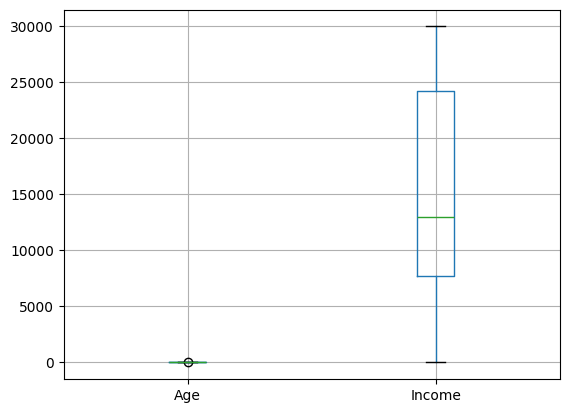

In [84]:
LU.boxplot()

In [85]:
LE = LabelEncoder()

In [86]:
# Calculate Q1 and Q3
Q1 = LU['Age'].quantile(0.25)
Q3 = LU['Age'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Define lower and upper limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Remove outliers
LU = LU[(LU['Age'] >= lower_limit) & (LU['Age'] <= upper_limit)]

<Axes: >

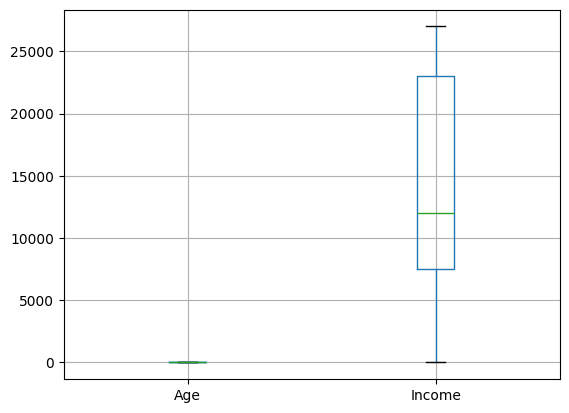

In [87]:
LU.boxplot()

In [88]:
LU.head()

,Age,Gender,Region,Occupation,Income,Has Laptop
0,14,male,city,student,0,no
1,34,female,city,teacher,22000,no
2,42,male,countryside,banker,24000,yes
3,30,male,countryside,teacher,25000,no
4,16,male,city,student,0,no


In [89]:
LU['Gender'] = LE.fit_transform(LU['Gender'])
LU['Region'] = LE.fit_transform(LU['Region'])
LU['Occupation'] = LE.fit_transform(LU['Occupation'])

In [90]:
X = LU[['Age', 'Gender', 'Region', 'Occupation', 'Income']]
Y = LU['Has Laptop']

In [91]:
X_train, X_test, Y_train, Y_test  = train_test_split(X, Y, test_size = 0.2, random_state = 46)

In [92]:
Has_or_Not = DecisionTreeClassifier()
Has_or_Not.fit(X_train, Y_train)

DecisionTreeClassifier()

In [93]:
Predict = Has_or_Not.predict(X_test)
Predict

array(['no', 'yes', 'no', 'yes'], dtype=object)

In [94]:
Score = accuracy_score(Y_test,Predict)
print(Score*100)

75.0


In [95]:
import pickle
pickle.dump(Has_or_Not, open('Has_Laptop_or_Not.pkl','wb'))
print('pkl file created succesfully')

pkl file created succesfully


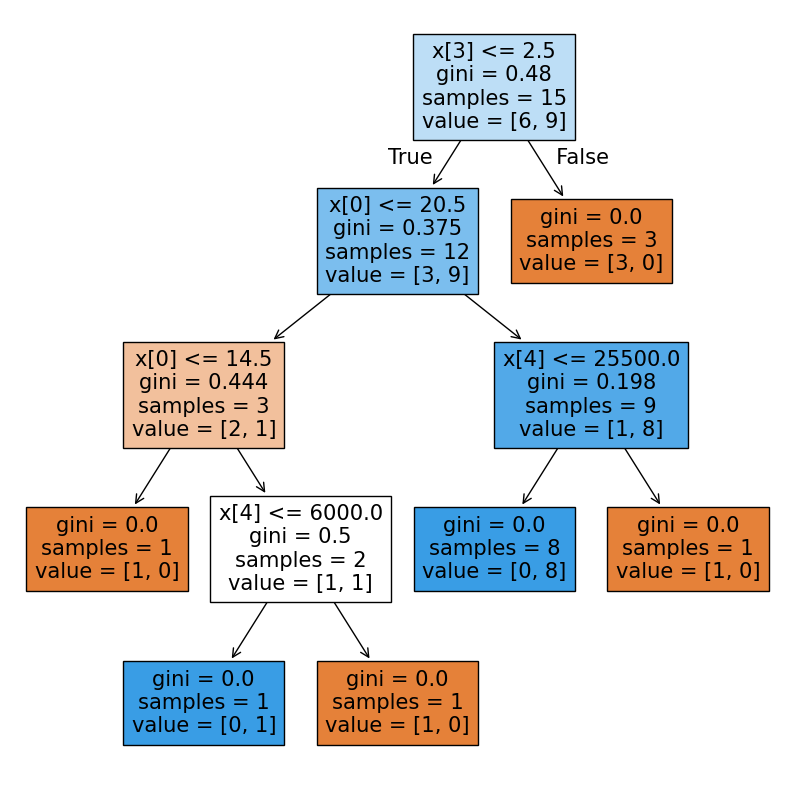

In [100]:
plt.figure(figsize=(10,10))
plot_tree(Has_or_Not,filled = True)
plt.show()